# WSI Preprocessing Pipeline — Camelyon16 Tumor Slides

Extract tile embeddings at 20x and 10x for each tumor WSI and save them to HDF5.

**Pipeline Overview:**
1. **Tiling**: 224x224 patches at 20x; 10x context image at the same level-0 coordinates (larger field of view)
2. **Tissue Masking**: HSV-based tissue/background classification from a low-resolution thumbnail to tile level
3. **Embedding**: Dual models with Self-Supervised ResNet18 + ImageNet ResNet18
4. **Output**: One HDF5 file per slide -> `{slide_id}.h5`

**HDF5 Schema:**

```
{slide_id}.h5
├── embeddings_20x_s      (N, D) float32     # SSL 20x tile embedding
├── embeddings_10x_s      (N, D) float32     # SSL 10x context embedding
├── embeddings_20x_i      (N, D) float32     # ImageNet 20x tile embedding
├── embeddings_10x_i      (N, D) float32     # ImageNet 10x context embedding
├── coords                (N, 2) int32       # level-0 absolute (x, y) coords
├── tissue_mask           (N,)   bool        # tissue flag per tile
├── thumbnail             (H,W,3) uint8      # low-res thumbnail
├── thumbnail_embedding_s (D,)   float32     # SSL thumbnail embedding
├── thumbnail_embedding_i (D,)   float32     # ImageNet thumbnail embedding
└── attrs: tile_size, level_20x, level_10x, mpp, slide_dimensions
```

> **Coordinate convention**: `coords` stores absolute level-0 pixel coordinates. `embeddings_20x` and `embeddings_10x` share the same level-0 coordinates, while reading at different levels yields different physical coverage.
> The 10x context image is one-to-one aligned with the 20x tile; at the same coordinate, its field of view is approximately a 2x2 area of the 20x tile.

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as T
import h5py
import numpy as np
import openslide
import cv2
from pathlib import Path
from scipy.ndimage import maximum_filter
from PIL import Image
import time

print(f"torch     : {torch.__version__}")
print(f"openslide : {openslide.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device    : {device}")

torch     : 2.5.1
openslide : 1.4.1
device    : cuda


In [ ]:
# --- Paths ------------------------------------------------------------------
SLIDE_DIR  = Path("data/camelyon16/training/tumor")
H5_OUT_DIR = Path("tile_database")
CKPT_PATH  = Path("pre_trained_resnet/self-supervised-histopathology/"
                   "pytorchnative_tenpercent_resnet18.ckpt")

# ─── Tiling ──────────────────────────────────────────────────────────────
TILE_SIZE  = 224
BATCH_SIZE = 128

# ─── Tissue Mask ─────────────────────────────────────────────────────────
S_THRESH       = 4       # HSV Saturation threshold
V_THRESH       = 130     # HSV Value threshold
MIN_AREA_RATIO = 0.05    # connected-component area filter ratio
TISSUE_THRESH  = 0.3     # tile-level tissue pixel ratio threshold

H5_OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Slide dir  : {SLIDE_DIR}")
print(f"Output dir : {H5_OUT_DIR}")
print(f"Checkpoint : {CKPT_PATH}")

Slide dir  : data\camelyon16\training\tumor
Output dir : tile_database
Checkpoint : pre_trained_resnet\self-supervised-histopathology\pytorchnative_tenpercent_resnet18.ckpt


## Load Models

Self-Supervised ResNet18 (ozanciga) + ImageNet-pretrained ResNet18, both with the classifier head removed to output 512-dim embeddings.

In [3]:
# ─── Self-Supervised ResNet18 ─────────────────────────────────────────────
model_ssl = models.resnet18(weights=None)
model_ssl.fc = torch.nn.Identity()

state = torch.load(str(CKPT_PATH), map_location='cpu')
sd = state.get('state_dict', state)

def strip_prefix(sd, prefixes=('model.', 'encoder.', 'backbone.', 'net.', 'resnet.')):
    for pfx in prefixes:
        remapped = {k[len(pfx):]: v for k, v in sd.items() if k.startswith(pfx)}
        if len(remapped) >= 10:
            return remapped
    return sd

sd = strip_prefix(sd)
missing, unexpected = model_ssl.load_state_dict(sd, strict=False)
model_ssl = model_ssl.to(device).eval()
print(f"[SSL]     loaded | missing={len(missing)}, unexpected={len(unexpected)}")

# ─── ImageNet Pretrained ResNet18 ─────────────────────────────────────────
model_inet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_inet.fc = torch.nn.Identity()
model_inet = model_inet.to(device).eval()
print("[ImageNet] loaded")

# ─── Transform & embedding dimension ────────────────────────────────────
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

with torch.no_grad():
    EMB_DIM = model_ssl(torch.randn(1, 3, 224, 224, device=device)).shape[1]
print(f"Embedding dim: {EMB_DIM}")

C:\Users\chenk\AppData\Local\Temp\ipykernel_8712\3491513257.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(CKPT_PATH), map_location='cpu')


[SSL]     loaded | missing=100, unexpected=124
[ImageNet] loaded
Embedding dim: 512


## Helper Functions

- `compute_tissue_mask`: HSV thresholding + morphology + connected-component filtering on the thumbnail level
- `get_tile_tissue_grid`: resize tissue mask to the tile grid
- `embed_indices`: batched inference for selected tile indices with both SSL and ImageNet models

In [ ]:
def compute_tissue_mask(slide):
    """
    Compute a tissue mask on a low-resolution thumbnail
    (the lowest level with width >= 800 px).
    Returns: (tissue_mask_uint8, thumbnail_rgb_uint8, thumbnail_level)
    """
    level_low = slide.level_count - 1
    for lvl in range(slide.level_count - 1, -1, -1):
        if slide.level_dimensions[lvl][0] >= 800:
            level_low = lvl
            break

    thumb_dims = slide.level_dimensions[level_low]
    thumb_np = np.array(
        slide.read_region((0, 0), level_low, thumb_dims).convert('RGB')
    )

    # HSV thresholding: low saturation + high value = background
    hsv = cv2.cvtColor(thumb_np, cv2.COLOR_RGB2HSV)
    S, V = hsv[:, :, 1], hsv[:, :, 2]
    tissue_m = (~((S < S_THRESH) & (V > V_THRESH))).astype(np.uint8) * 255

    # Morphological closing
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    tissue_m = cv2.morphologyEx(tissue_m, cv2.MORPH_CLOSE, kernel, iterations=5)

    # Connected-component filtering: keep only regions with area
    # >= max_component_area * MIN_AREA_RATIO
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        tissue_m, connectivity=8
    )
    if n_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        keep = np.where(areas >= areas.max() * MIN_AREA_RATIO)[0] + 1
        tissue_m = np.isin(labels, keep).astype(np.uint8) * 255

    return tissue_m, thumb_np, level_low


def get_tile_tissue_grid(tissue_mask_img, n_cols, n_rows):
    """Resize tissue mask to tile-grid size and return bool [n_rows, n_cols]."""
    tile_ratio = cv2.resize(
        tissue_mask_img.astype(np.float32) / 255,
        (n_cols, n_rows),
        interpolation=cv2.INTER_AREA,
    )
    return tile_ratio >= TISSUE_THRESH


@torch.no_grad()
def embed_indices(slide, indices, level, coords):
    """
    Compute embeddings with both SSL and ImageNet models
    for tiles specified by `indices`.
    Returns (emb_s, emb_i), shape=(N_total, EMB_DIM),
    with zero vectors at non-target indices.
    """
    N_total = len(coords)
    emb_s = np.zeros((N_total, EMB_DIM), dtype=np.float32)
    emb_i = np.zeros((N_total, EMB_DIM), dtype=np.float32)

    n_batches = (len(indices) + BATCH_SIZE - 1) // BATCH_SIZE
    for b, start in enumerate(range(0, len(indices), BATCH_SIZE)):
        batch_idx = indices[start : start + BATCH_SIZE]
        images = [
            slide.read_region(
                (int(coords[j, 0]), int(coords[j, 1])),
                level,
                (TILE_SIZE, TILE_SIZE),
            ).convert('RGB')
            for j in batch_idx
        ]
        tensors = torch.stack([transform(img) for img in images]).to(device)
        emb_s[batch_idx] = model_ssl(tensors).cpu().numpy()
        emb_i[batch_idx] = model_inet(tensors).cpu().numpy()

        if (b + 1) % 20 == 0 or (b + 1) == n_batches:
            done = min(start + BATCH_SIZE, len(indices))
            print(f"    [{done}/{len(indices)}]")

    return emb_s, emb_i


print("Helper functions defined.")

Helper functions defined.


## Single-WSI Processing Function

`process_single_slide(slide_path, h5_out_path)` — complete pipeline

In [ ]:
def process_single_slide(slide_path, h5_out_path):
    """Process one WSI: tiling + tissue mask + dual-model embedding -> HDF5."""
    t0 = time.time()
    slide_id = Path(slide_path).stem
    slide = openslide.OpenSlide(str(slide_path))

    # ── 1. Level info ────────────────────────────────────────────────────
    level_20x = slide.get_best_level_for_downsample(40.0 / 20)
    level_10x = slide.get_best_level_for_downsample(40.0 / 10)
    ds_20x = slide.level_downsamples[level_20x]
    ds_10x = slide.level_downsamples[level_10x]
    w_20x, h_20x = slide.level_dimensions[level_20x]
    n_cols = w_20x // TILE_SIZE
    n_rows = h_20x // TILE_SIZE
    N = n_cols * n_rows
    slide_dims = slide.dimensions
    mpp = float(slide.properties.get('openslide.mpp-x', 0))

    print(f"[{slide_id}] 20x: level={level_20x} ds={ds_20x:.1f} | "
          f"10x: level={level_10x} ds={ds_10x:.1f}")
    print(f"  grid {n_cols}x{n_rows}={N} tiles | slide {slide_dims} | mpp={mpp:.4f}")

    # ── 2. Tissue mask ───────────────────────────────────────────────────
    tissue_mask_img, thumb_np, _ = compute_tissue_mask(slide)
    tile_tissue = get_tile_tissue_grid(tissue_mask_img, n_cols, n_rows)
    tissue_flat = tile_tissue.ravel()   # (N,) bool
    n_tissue = int(tissue_flat.sum())
    print(f"  tissue: {n_tissue}/{N} ({n_tissue/N:.1%})")

    # ── 3. Level-0 absolute coords (x, y) ────────────────────────────────
    col_mesh, row_mesh = np.meshgrid(np.arange(n_cols), np.arange(n_rows))
    coords = np.stack([
        (col_mesh * TILE_SIZE * ds_20x).astype(np.int32).ravel(),
        (row_mesh * TILE_SIZE * ds_20x).astype(np.int32).ravel(),
    ], axis=1)   # (N, 2)

    # -- 4. 10x context: if any tissue tile exists in a 3x3 neighborhood,
    #           this tile needs embedding
    ctx_needs = maximum_filter(
        tile_tissue.astype(np.uint8), size=3, mode='constant', cval=0
    ) > 0
    ctx_flat = ctx_needs.ravel()
    n_ctx = int(ctx_flat.sum())
    print(f"  10x context need embed: {n_ctx}/{N} ({n_ctx/N:.1%})")

    tissue_idx  = np.where(tissue_flat)[0]
    context_idx = np.where(ctx_flat)[0]

    # ── 5. 20x embeddings (tissue only, rest = zero) ─────────────────────
    print(f"  [20x] embedding {len(tissue_idx)} tissue tiles ...")
    emb_20x_s, emb_20x_i = embed_indices(slide, tissue_idx, level_20x, coords)

    # ── 6. 10x embeddings (context only, rest = zero) ────────────────────
    print(f"  [10x] embedding {len(context_idx)} context tiles ...")
    emb_10x_s, emb_10x_i = embed_indices(slide, context_idx, level_10x, coords)

    # ── 7. Thumbnail + thumbnail embedding ───────────────────────────────
    thumb_pil = Image.fromarray(thumb_np).resize(
        (TILE_SIZE, TILE_SIZE), Image.LANCZOS
    )
    thumb_t = transform(thumb_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        thumb_emb_s = model_ssl(thumb_t).cpu().numpy().squeeze()
        thumb_emb_i = model_inet(thumb_t).cpu().numpy().squeeze()
    print(f"  thumbnail: {thumb_np.shape}")

    slide.close()

    # ── 8. Save HDF5 ────────────────────────────────────────────────────
    with h5py.File(h5_out_path, 'w') as f:
        f.create_dataset('embeddings_20x_s', data=emb_20x_s,
                         compression='gzip', chunks=True)
        f.create_dataset('embeddings_10x_s', data=emb_10x_s,
                         compression='gzip', chunks=True)
        f.create_dataset('embeddings_20x_i', data=emb_20x_i,
                         compression='gzip', chunks=True)
        f.create_dataset('embeddings_10x_i', data=emb_10x_i,
                         compression='gzip', chunks=True)
        f.create_dataset('coords',      data=coords, compression='gzip')
        f.create_dataset('tissue_mask', data=tissue_flat)
        f.create_dataset('thumbnail',   data=thumb_np)
        f.create_dataset('thumbnail_embedding_s', data=thumb_emb_s)
        f.create_dataset('thumbnail_embedding_i', data=thumb_emb_i)

        f.attrs['tile_size']        = TILE_SIZE
        f.attrs['level_20x']        = level_20x
        f.attrs['level_10x']        = level_10x
        f.attrs['mpp']              = mpp
        f.attrs['slide_dimensions'] = np.array(slide_dims, dtype=np.int64)

    elapsed = time.time() - t0
    fsize = h5_out_path.stat().st_size / 1e6
    print(f"  => {h5_out_path.name} | {fsize:.1f} MB | {elapsed:.1f}s")
    return N, n_tissue


print("process_single_slide() defined.")

process_single_slide() defined.


## Single-WSI Test — tumor_001

Run the full pipeline once with `tumor_001.tif` and inspect the output.

In [6]:
test_slide = SLIDE_DIR / "tumor_001.tif"
test_h5    = H5_OUT_DIR / "tumor_001.h5"

n_total, n_tissue = process_single_slide(test_slide, test_h5)
print(f"\nDone. total_tiles={n_total}, tissue_tiles={n_tissue}")

[tumor_001] 20x: level=1 ds=2.0 | 10x: level=2 ds=4.0
  grid 218x493=107474 tiles | slide (97792, 221184) | mpp=0.2431
  tissue: 32710/107474 (30.4%)
  10x context need embed: 34484/107474 (32.1%)
  [20x] embedding 32710 tissue tiles ...
    [2560/32710]
    [5120/32710]
    [7680/32710]
    [10240/32710]
    [12800/32710]
    [15360/32710]
    [17920/32710]
    [20480/32710]
    [23040/32710]
    [25600/32710]
    [28160/32710]
    [30720/32710]
    [32710/32710]
  [10x] embedding 34484 context tiles ...
    [2560/34484]
    [5120/34484]
    [7680/34484]
    [10240/34484]
    [12800/34484]
    [15360/34484]
    [17920/34484]
    [20480/34484]
    [23040/34484]
    [25600/34484]
    [28160/34484]
    [30720/34484]
    [33280/34484]
    [34484/34484]
  thumbnail: (3456, 1528, 3)
  => tumor_001.h5 | 261.5 MB | 334.7s

Done. total_tiles=107474, tissue_tiles=32710


### Validate HDF5 Output

=== HDF5 Datasets ===
  coords                          shape=(107474, 2)           dtype=int32
  embeddings_10x_i                shape=(107474, 512)         dtype=float32
  embeddings_10x_s                shape=(107474, 512)         dtype=float32
  embeddings_20x_i                shape=(107474, 512)         dtype=float32
  embeddings_20x_s                shape=(107474, 512)         dtype=float32
  thumbnail                       shape=(3456, 1528, 3)       dtype=uint8
  thumbnail_embedding_i           shape=(512,)                dtype=float32
  thumbnail_embedding_s           shape=(512,)                dtype=float32
  tissue_mask                     shape=(107474,)             dtype=bool

=== Attributes ===
  level_10x            : 2
  level_20x            : 1
  mpp                  : 0.24309399999999998
  slide_dimensions     : [ 97792 221184]
  tile_size            : 224

tissue_mask True count  : 32710/107474
non-zero embeddings_20x_s: 32710
non-zero embeddings_10x_s: 34484


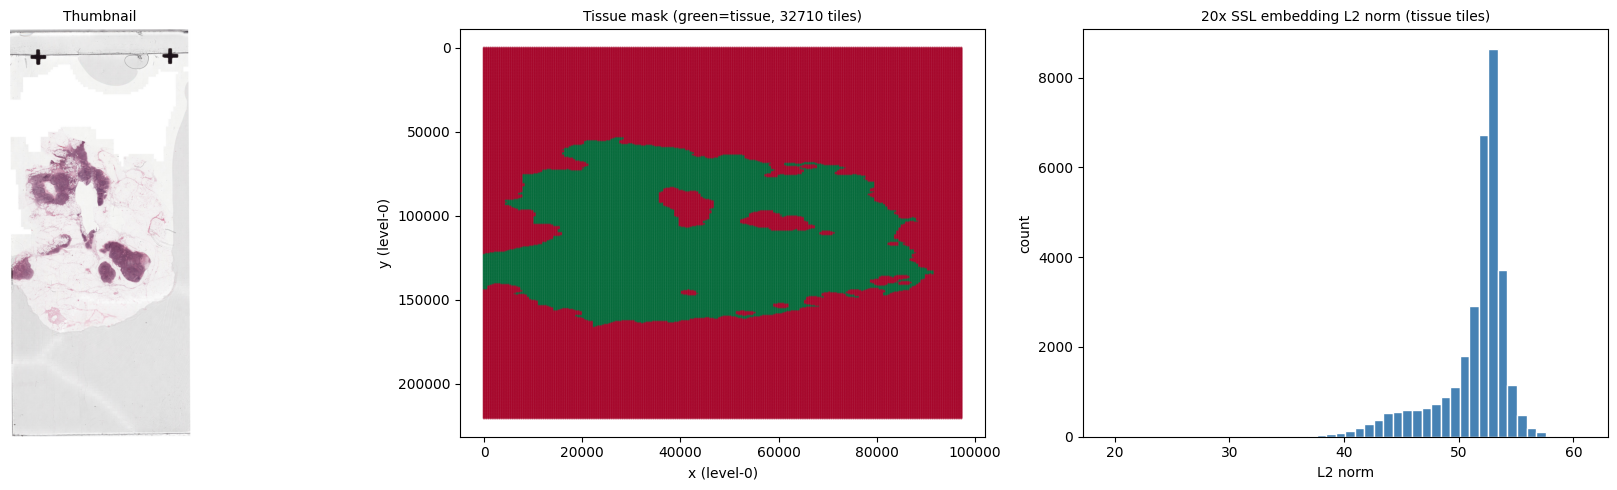

In [ ]:
import matplotlib.pyplot as plt

with h5py.File(test_h5, 'r') as f:
    print("=== HDF5 Datasets ===")
    for key in f.keys():
        ds = f[key]
        print(f"  {key:30s}  shape={str(ds.shape):20s}  dtype={ds.dtype}")
    print("\n=== Attributes ===")
    for k, v in f.attrs.items():
        print(f"  {k:20s} : {v}")

    coords_  = f['coords'][:]
    tissue_  = f['tissue_mask'][:]
    thumb_   = f['thumbnail'][:]
    emb_20s_ = f['embeddings_20x_s'][:]
    emb_10s_ = f['embeddings_10x_s'][:]

n_tissue_  = int(tissue_.sum())
n_nz_20s   = int((np.abs(emb_20s_).sum(axis=1) > 0).sum())
n_nz_10s   = int((np.abs(emb_10s_).sum(axis=1) > 0).sum())
print(f"\ntissue_mask True count  : {n_tissue_}/{len(tissue_)}")
print(f"non-zero embeddings_20x_s: {n_nz_20s}")
print(f"non-zero embeddings_10x_s: {n_nz_10s}")

# --- Visualization -----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: thumbnail
axes[0].imshow(thumb_)
axes[0].set_title("Thumbnail", fontsize=10)
axes[0].axis('off')

# Middle: spatial distribution of tile-level tissue mask
sc = axes[1].scatter(
    coords_[:, 0], coords_[:, 1],
    c=tissue_.astype(float), cmap='RdYlGn', s=1, alpha=0.5
)
axes[1].invert_yaxis()
axes[1].set_title(f"Tissue mask (green=tissue, {n_tissue_} tiles)", fontsize=10)
axes[1].set_xlabel("x (level-0)")
axes[1].set_ylabel("y (level-0)")

# Right: distribution of 20x SSL embedding L2 norms
norms = np.linalg.norm(emb_20s_, axis=1)
tissue_norms = norms[tissue_]
axes[2].hist(tissue_norms, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title("20x SSL embedding L2 norm (tissue tiles)", fontsize=10)
axes[2].set_xlabel("L2 norm")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

## Batch Process All Tumor Slides

Iterate through all `tumor_*.tif`; automatically skip existing HDF5 files (useful for resume runs).

In [8]:
slide_paths = sorted(SLIDE_DIR.glob("tumor_*.tif"))
print(f"Total slides found: {len(slide_paths)}")

results = []
t_all = time.time()

for i, tif_path in enumerate(slide_paths):
    slide_id = tif_path.stem
    h5_path = H5_OUT_DIR / f"{slide_id}.h5"

    if h5_path.exists():
        print(f"[{i+1}/{len(slide_paths)}] {slide_id} -- SKIP (exists)")
        continue

    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(slide_paths)}] Processing {slide_id}")
    print('='*60)
    try:
        n_total, n_tissue = process_single_slide(tif_path, h5_path)
        results.append((slide_id, n_total, n_tissue, "OK"))
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append((slide_id, 0, 0, str(e)))

elapsed_all = time.time() - t_all
print(f"\n{'='*60}")
print("BATCH PROCESSING SUMMARY")
print('='*60)
ok_count   = sum(1 for r in results if r[3] == "OK")
fail_count = len(results) - ok_count
skip_count = len(slide_paths) - len(results)
print(f"Processed: {ok_count} | Skipped: {skip_count} | Failed: {fail_count}")
print(f"Total time: {elapsed_all:.0f}s ({elapsed_all/60:.1f} min)")
for sid, nt, ntis, status in results:
    tag = "OK" if status == "OK" else "FAIL"
    print(f"  [{tag:4s}] {sid}: N={nt}, tissue={ntis}")

Total slides found: 111
[1/111] tumor_001 -- SKIP (exists)

[2/111] Processing tumor_002
[tumor_002] 20x: level=1 ds=2.0 | 10x: level=2 ds=4.0
  grid 218x490=106820 tiles | slide (97792, 219648) | mpp=0.2431
  tissue: 17035/106820 (15.9%)
  10x context need embed: 19234/106820 (18.0%)
  [20x] embedding 17035 tissue tiles ...
    [2560/17035]
    [5120/17035]
    [7680/17035]
    [10240/17035]
    [12800/17035]
    [15360/17035]
    [17035/17035]
  [10x] embedding 19234 context tiles ...
    [2560/19234]
    [5120/19234]
    [7680/19234]
    [10240/19234]
    [12800/19234]
    [15360/19234]
    [17920/19234]
    [19234/19234]
  thumbnail: (3432, 1528, 3)
  => tumor_002.h5 | 149.0 MB | 177.5s

[3/111] Processing tumor_003
[tumor_003] 20x: level=1 ds=2.0 | 10x: level=2 ds=4.0
  grid 218x493=107474 tiles | slide (97792, 221184) | mpp=0.2431
  tissue: 20050/107474 (18.7%)
  10x context need embed: 23093/107474 (21.5%)
  [20x] embedding 20050 tissue tiles ...
    [2560/20050]
    [5120/20050